# Financial Inclusion and Gender Analysis

## Introduction

Financial inclusion plays an important role in improving individuals' access to financial services and their ability to participate in economic activities. However, access to and use of financial services may differ across countries and between men and women.

This project analyses financial inclusion indicators across countries using data from the Global Findex dataset. The analysis focuses on patterns of financial access and usage, gender differences, changes over time, and Kenya's position relative to Sub-Saharan Africa and the wider world.

The analysis uses indicators covering account ownership, access to financial institutions, mobile money, saving, borrowing, digital payments and internet use. Gender-disaggregated data is used to examine differences between men and women.

## Research Questions

1. What are the main patterns of financial inclusion across countries?
2. How does financial inclusion differ between men and women?
3. How large is the gender gap in selected financial inclusion indicators?
4. How has financial inclusion changed over time?
5. How does Kenya compare with Sub-Saharan Africa and the global picture?
6. Are observed differences between men and women statistically significant?

## Objectives

- Examine the distribution of financial inclusion indicators across countries.
- Assess gender differences in financial inclusion.
- Analyse changes in selected indicators over time.
- Evaluate Kenya's financial inclusion position against regional and global benchmarks.
- Apply statistical analysis to assess whether observed gender differences are significant.

## 1. Setup and Data Loading

In [70]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset
df = pd.read_excel("data/GlobalFindexGenderInclusion.xlsx")

# Display the first five rows
df.head()

,country,country_code,region,income_group,year,indicator_code,indicator_name,topic,gender_group,value_pct
0,Afghanistan,AFG,South Asia (excluding high income),Low income,2011,account.t.d,Account ownership,Access,All adults,9.01
1,Afghanistan,AFG,South Asia (excluding high income),Low income,2014,account.t.d,Account ownership,Access,All adults,9.96
2,Afghanistan,AFG,South Asia (excluding high income),Low income,2017,account.t.d,Account ownership,Access,All adults,14.89
3,Afghanistan,AFG,South Asia (excluding high income),Low income,2017,account.t.d,Account ownership,Access,men,22.54
4,Afghanistan,AFG,South Asia (excluding high income),Low income,2017,account.t.d,Account ownership,Access,women,7.16


## 2. Initial Data Inspection

In [3]:
# Dataset dimensions
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 15,593
Columns: 10


In [4]:
# Dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15593 entries, 0 to 15592
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         15593 non-null  object 
 1   country_code    15593 non-null  object 
 2   region          14391 non-null  object 
 3   income_group    14391 non-null  object 
 4   year            15593 non-null  int64  
 5   indicator_code  15593 non-null  object 
 6   indicator_name  15593 non-null  object 
 7   topic           15593 non-null  object 
 8   gender_group    15593 non-null  object 
 9   value_pct       15593 non-null  float64
dtypes: float64(1), int64(1), object(8)
memory usage: 1.2+ MB


In [5]:
# Missing values by column
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

,0
income_group,1202
region,1202
country_code,0
country,0
year,0
indicator_code,0
indicator_name,0
topic,0
gender_group,0
value_pct,0


In [6]:
# Check for duplicate records
print(f"Duplicate rows: {df.duplicated().sum():,}")

Duplicate rows: 0


In [7]:
# Key dataset dimensions
print(f"Countries: {df['country'].nunique():,}")
print(f"Years: {df['year'].nunique():,}")
print(f"Indicators: {df['indicator_name'].nunique():,}")
print(f"Gender groups: {df['gender_group'].nunique():,}")

Countries: 174
Years: 6
Indicators: 10
Gender groups: 3


In [8]:
# Years covered
sorted(df['year'].unique())

[np.int64(2011),
 np.int64(2014),
 np.int64(2017),
 np.int64(2021),
 np.int64(2022),
 np.int64(2024)]

In [9]:
# Financial inclusion indicators
df[['indicator_code', 'indicator_name', 'topic']].drop_duplicates().sort_values(
    ['topic', 'indicator_name']
)

,indicator_code,indicator_name,topic
0,account.t.d,Account ownership,Access
15,fiaccount.t.d,Bank/financial institution account,Access
25,fin2.t.d,Debit card ownership,Access
37,mobileaccount.t.d,Mobile money account,Access
131,internet,Used the internet (past 3 months),Digital access
6,borrow.any.t.d,Borrowed any money (any source),Usage
29,fin22a,Borrowed from a formal financial institution,Usage
32,g20.any,Made or received a digital payment,Usage
40,save.any.t.d,Saved any money (any method),Usage
21,fin17a,Saved at a bank/financial institution,Usage


## 3. Data Cleaning and Preparation

The dataset contains observations for individual countries as well as regional and income-group aggregates. Since the analysis focuses primarily on country-level financial inclusion patterns, country observations are separated from aggregate observations.

The data is also checked for missing values and duplicate records before analysis.

In [11]:
# Separate country-level observations from regional and income-group aggregates

countries = df[df['region'].notna()].copy()
aggregates = df[df['region'].isna()].copy()

print(f"Country-level observations: {len(countries):,}")
print(f"Aggregate observations: {len(aggregates):,}")

Country-level observations: 14,391
Aggregate observations: 1,202


In [12]:
# Country coverage

country_count = countries[['country', 'country_code']].drop_duplicates().shape[0]

print(f"Unique countries: {country_count:,}")
print(f"Years covered: {countries['year'].min()}–{countries['year'].max()}")

Unique countries: 162
Years covered: 2011–2024


In [13]:
# Gender groups available

countries['gender_group'].value_counts()

,count
gender_group,
All adults,5359
men,4516
women,4516


In [14]:
# Gender groups by indicator

gender_by_indicator = (
    countries.groupby(['indicator_name', 'gender_group'])
    .size()
    .unstack(fill_value=0)
)

gender_by_indicator

gender_group,All adults,men,women
indicator_name,,,
Account ownership,712,686,686
Bank/financial institution account,712,677,677
Borrowed any money (any source),525,525,525
Borrowed from a formal financial institution,525,264,264
Debit card ownership,712,576,576
Made or received a digital payment,525,499,499
Mobile money account,313,179,179
Saved any money (any method),525,524,524
Saved at a bank/financial institution,669,445,445


In [15]:
# Indicator coverage

indicator_summary = (
    countries[['indicator_code', 'indicator_name', 'topic']]
    .drop_duplicates()
    .sort_values(['topic', 'indicator_name'])
)

indicator_summary

,indicator_code,indicator_name,topic
0,account.t.d,Account ownership,Access
15,fiaccount.t.d,Bank/financial institution account,Access
25,fin2.t.d,Debit card ownership,Access
37,mobileaccount.t.d,Mobile money account,Access
131,internet,Used the internet (past 3 months),Digital access
6,borrow.any.t.d,Borrowed any money (any source),Usage
29,fin22a,Borrowed from a formal financial institution,Usage
32,g20.any,Made or received a digital payment,Usage
40,save.any.t.d,Saved any money (any method),Usage
21,fin17a,Saved at a bank/financial institution,Usage


In [16]:
# Validate percentage values

print(f"Minimum value: {countries['value_pct'].min():.2f}%")
print(f"Maximum value: {countries['value_pct'].max():.2f}%")

Minimum value: 0.00%
Maximum value: 100.00%


In [17]:
# Check for values outside the valid percentage range

invalid_values = countries[
    (countries['value_pct'] < 0) |
    (countries['value_pct'] > 100)
]

print(f"Invalid percentage values: {len(invalid_values):,}")

Invalid percentage values: 0


In [18]:
# Final data-quality check

print("Missing values:")
print(countries.isnull().sum())

print("\nDuplicate rows:")
print(countries.duplicated().sum())

Missing values:
country           0
country_code      0
region            0
income_group      0
year              0
indicator_code    0
indicator_name    0
topic             0
gender_group      0
value_pct         0
dtype: int64

Duplicate rows:
0


## 4. Global Financial Inclusion Overview

This section provides an overview of financial inclusion across countries in the dataset. The analysis compares the average level of access and use across the available indicators and identifies areas where financial inclusion is relatively strong or limited.

Country-level observations are used to avoid mixing individual countries with regional and income-group aggregates.

In [19]:
# Global financial inclusion summary

global_summary = (
    countries
    .groupby(['indicator_name', 'topic'])['value_pct']
    .agg(
        mean='mean',
        median='median',
        std='std',
        minimum='min',
        maximum='max'
    )
    .round(2)
    .sort_values('mean', ascending=False)
)

global_summary

,,mean,median,std,minimum,maximum
indicator_name,topic,,,,,
Used the internet (past 3 months),Digital access,73.78,83.19,23.47,7.17,99.57
Account ownership,Access,61.24,62.26,28.58,0.40,100.00
Bank/financial institution account,Access,58.19,57.56,30.55,0.40,100.00
Made or received a digital payment,Usage,54.61,51.76,27.75,4.08,100.00
Borrowed any money (any source),Usage,51.32,49.39,14.14,15.43,93.11
Saved any money (any method),Usage,51.14,50.26,17.32,5.62,92.02
Debit card ownership,Access,48.30,44.32,30.63,0.27,99.49
Saved at a bank/financial institution,Usage,26.74,20.55,18.86,0.12,83.87
Mobile money account,Access,25.89,21.49,19.12,0.00,91.67


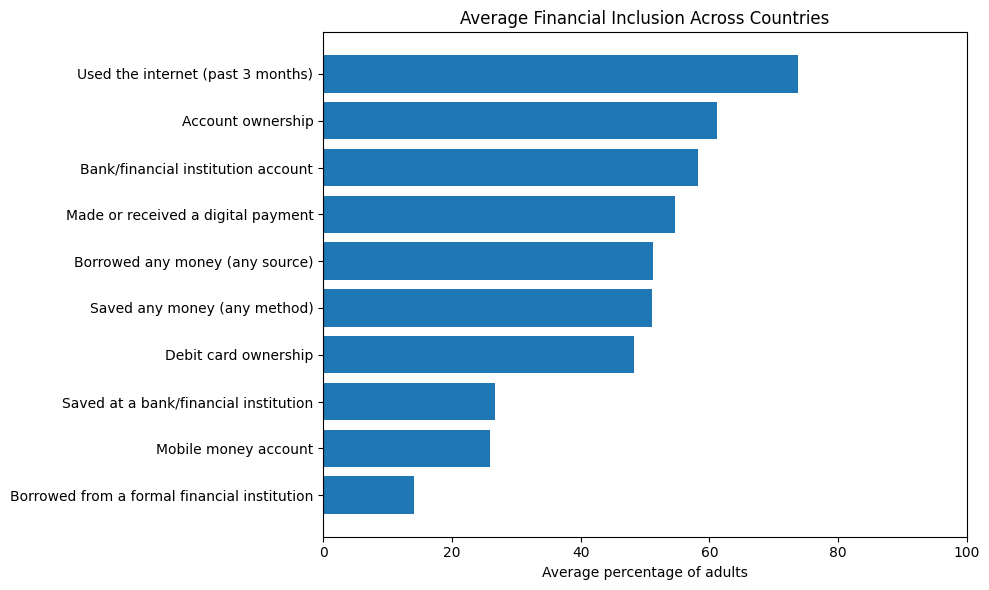

In [20]:
# Average financial inclusion by indicator

plot_data = (
    global_summary
    .reset_index()
    .sort_values('mean', ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data['indicator_name'],
    plot_data['mean']
)

plt.xlabel('Average percentage of adults')
plt.ylabel('')
plt.title('Average Financial Inclusion Across Countries')
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

### Interpretation

Internet use has the highest average level among the indicators analysed, followed by account ownership and access to bank or financial institution accounts. Digital payments also show relatively high levels of adoption.

In contrast, formal borrowing and saving through a bank or financial institution record substantially lower average levels. This suggests that access to basic financial services is generally more widespread than the use of formal financial products such as institutional saving and borrowing.

In [21]:
# Identify highest and lowest indicators

highest_indicator = global_summary['mean'].idxmax()
lowest_indicator = global_summary['mean'].idxmin()

highest_value = global_summary.loc[highest_indicator, 'mean']
lowest_value = global_summary.loc[lowest_indicator, 'mean']

print(f"Highest average indicator: {highest_indicator} ({highest_value:.2f}%)")
print(f"Lowest average indicator: {lowest_indicator} ({lowest_value:.2f}%)")

Highest average indicator: ('Used the internet (past 3 months)', 'Digital access') (73.78%)
Lowest average indicator: ('Borrowed from a formal financial institution', 'Usage') (14.12%)


## 5. Global Gender Gap in Financial Inclusion

This section examines differences in financial inclusion between men and women across countries and years.

The gender gap is measured as the percentage of men using or accessing a financial service minus the corresponding percentage for women. A positive value therefore indicates higher financial inclusion among men, while a negative value indicates higher financial inclusion among women.

The analysis focuses on matched observations where both male and female values are available.

In [22]:
# Prepare matched male and female observations

gender_data = countries[
    countries['gender_group'].isin(['men', 'women'])
].copy()

gender = (
    gender_data
    .pivot_table(
        index=[
            'country',
            'country_code',
            'region',
            'income_group',
            'year',
            'indicator_name'
        ],
        columns='gender_group',
        values='value_pct'
    )
    .reset_index()
)

# Calculate gender gap in percentage points
gender['gender_gap_pp'] = gender['men'] - gender['women']

gender.head()

gender_group,country,country_code,region,income_group,year,indicator_name,men,women,gender_gap_pp
0,Afghanistan,AFG,South Asia (excluding high income),Low income,2014,Borrowed any money (any source),41.12,28.26,12.86
1,Afghanistan,AFG,South Asia (excluding high income),Low income,2014,Saved any money (any method),31.81,19.39,12.42
2,Afghanistan,AFG,South Asia (excluding high income),Low income,2017,Account ownership,22.54,7.16,15.38
3,Afghanistan,AFG,South Asia (excluding high income),Low income,2017,Bank/financial institution account,22.36,6.64,15.72
4,Afghanistan,AFG,South Asia (excluding high income),Low income,2017,Borrowed any money (any source),36.21,31.60,4.61


In [23]:
# Overall gender gap summary

gender_gap_summary = (
    gender['gender_gap_pp']
    .describe()
    .round(2)
)

gender_gap_summary

,gender_gap_pp
count,4516.00
mean,5.40
std,6.87
min,-16.68
25%,0.64
50%,4.46
75%,8.90
max,57.49


In [24]:
# Gender gap by financial inclusion indicator

gender_gap_by_indicator = (
    gender
    .groupby('indicator_name')['gender_gap_pp']
    .agg(
        mean_gap='mean',
        median_gap='median',
        observations='count'
    )
    .round(2)
    .sort_values('mean_gap', ascending=False)
)

gender_gap_by_indicator

,mean_gap,median_gap,observations
indicator_name,,,
Mobile money account,7.07,6.63,179
Made or received a digital payment,6.99,6.52,499
Account ownership,6.19,4.70,686
Bank/financial institution account,5.84,4.20,677
Debit card ownership,5.82,4.40,576
Used the internet (past 3 months),4.64,2.70,141
Saved any money (any method),4.52,4.48,524
Saved at a bank/financial institution,4.45,4.40,445
Borrowed any money (any source),4.33,3.95,525


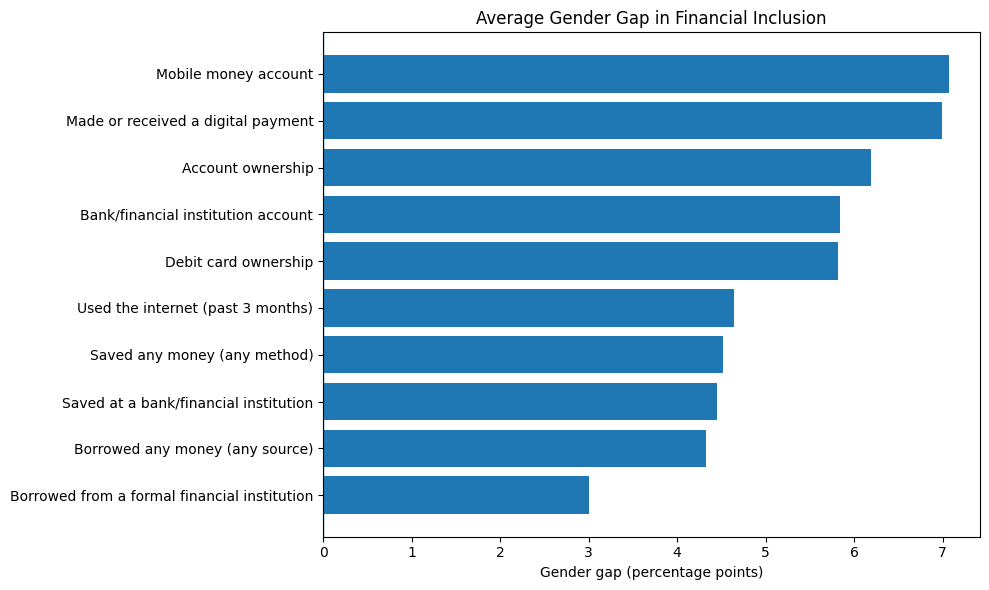

In [25]:
# Average gender gap by indicator

plot_data = (
    gender_gap_by_indicator
    .sort_values('mean_gap')
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data.index,
    plot_data['mean_gap']
)

plt.axvline(0, linewidth=1)

plt.xlabel('Gender gap (percentage points)')
plt.ylabel('')
plt.title('Average Gender Gap in Financial Inclusion')
plt.tight_layout()
plt.show()

In [26]:
# Direction of the gender gap

gender_direction = pd.Series({
    'Men higher': (gender['gender_gap_pp'] > 0).mean() * 100,
    'Women higher': (gender['gender_gap_pp'] < 0).mean() * 100,
    'Equal': (gender['gender_gap_pp'] == 0).mean() * 100
})

gender_direction.round(2)

,0
Men higher,79.07
Women higher,20.57
Equal,0.35


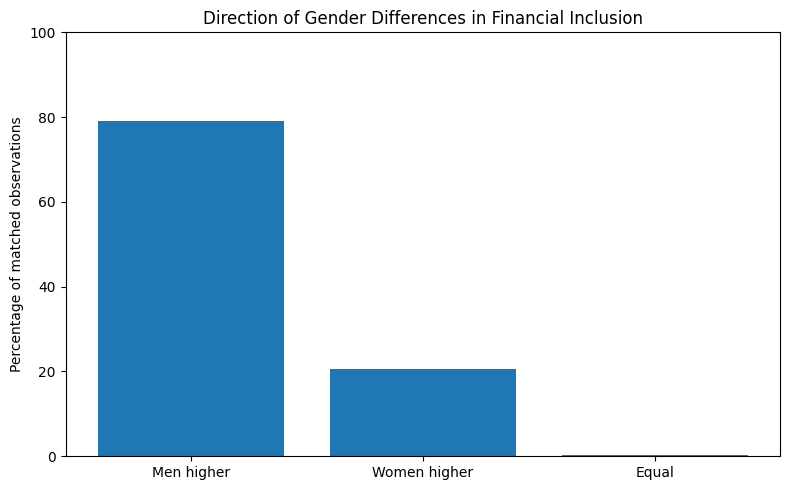

In [27]:
# Direction of gender differences

plt.figure(figsize=(8, 5))

plt.bar(
    gender_direction.index,
    gender_direction.values
)

plt.ylabel('Percentage of matched observations')
plt.title('Direction of Gender Differences in Financial Inclusion')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

**GLOBAL DISTRIBUTIONS OF FINANCIAL INCLUSION INDICATORS**

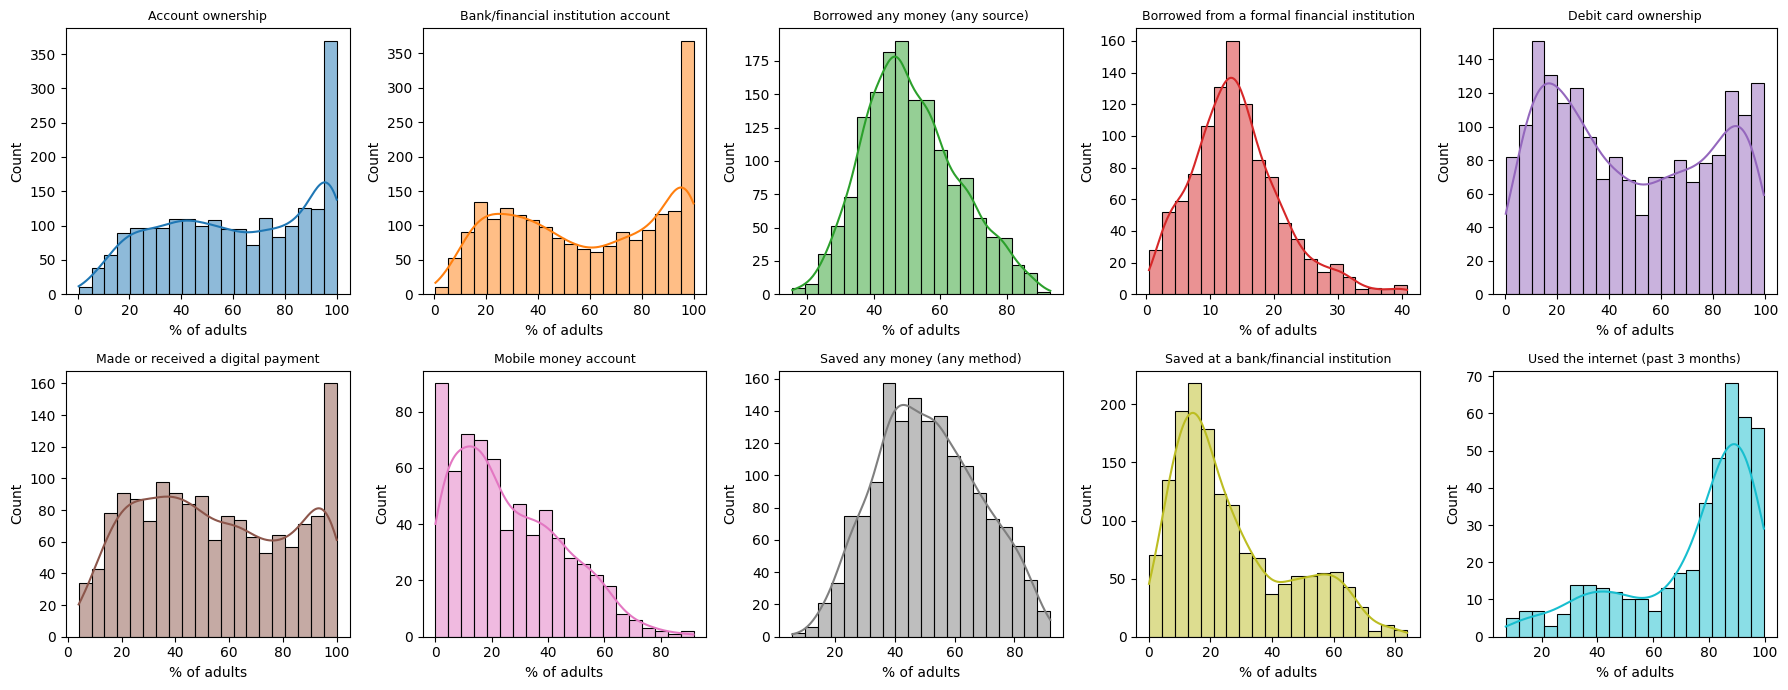

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
palette = sns.color_palette("tab10", 10)

for ax, (indicator, data), colour in zip(
    axes.flat, countries.groupby('indicator_name'), palette
):
    sns.histplot(data=data, x='value_pct', bins=20, kde=True, color=colour, ax=ax)
    ax.set_title(indicator, fontsize=9)
    ax.set_xlabel('% of adults')

plt.tight_layout()
plt.show()

Overall, the distributions show considerable variation in financial inclusion across countries. Account ownership, digital payments and internet use tend to be concentrated at higher levels, while formal borrowing, saving through financial institutions and mobile money account ownership generally remain lower and more unevenly distributed

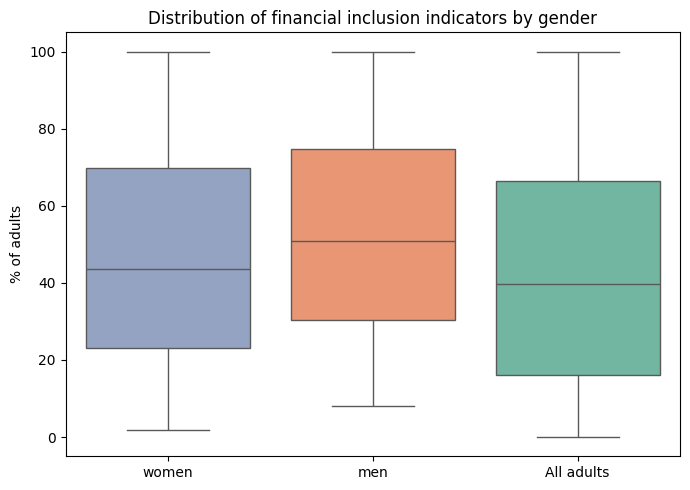

In [35]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=countries,
    x='gender_group',
    y='value_pct',
    hue='gender_group',
    order=['women', 'men', 'All adults'],
    palette='Set2',
    legend=False
)

plt.title('Distribution of financial inclusion indicators by gender')
plt.xlabel('')
plt.ylabel('% of adults')

plt.tight_layout()
plt.show()

The boxplot shows a clear gender difference in financial inclusion, with men having a higher median value than women. However, the wide spread of the distributions indicates substantial variation across countries and indicators

CORRELATION BETWEEN FINNCIAL INCLUSION INDICATORS

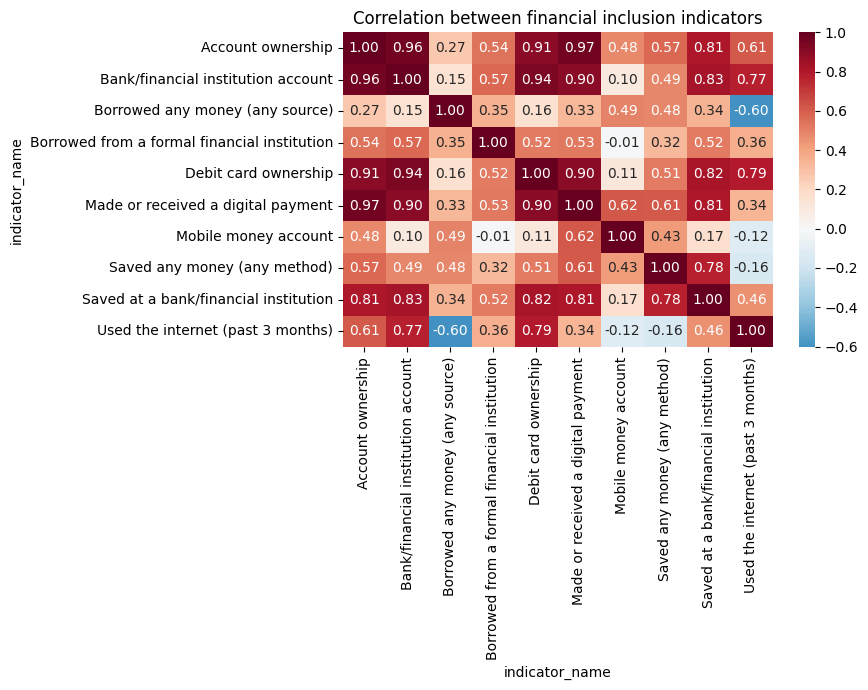

In [34]:
all_adults = countries[countries['gender_group'] == 'All adults']

wide = all_adults.pivot_table(
    index=['country', 'year'],
    columns='indicator_name',
    values='value_pct'
)

corr = wide.corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0
)

plt.title('Correlation between financial inclusion indicators')
plt.tight_layout()
plt.show()

The correlation analysis shows a strong relationship between formal financial access, account ownership, digital payments and debit card ownership. Internet use is also positively associated with several formal financial inclusion indicators. In contrast, general borrowing and mobile money ownership show weaker and more mixed relationships with other indicators.

In [31]:
# Unadjusted paired t-test: men vs women

test_data = gender.dropna(subset=['men', 'women'])

t_stat, p_value = stats.ttest_rel(
    test_data['men'],
    test_data['women']
)

test_results = pd.DataFrame({
    'Measure': [
        'Matched observations',
        'Mean male value (%)',
        'Mean female value (%)',
        'Mean gender gap (pp)',
        'Median gender gap (pp)',
        't-statistic',
        'p-value'
    ],
    'Value': [
        len(test_data),
        test_data['men'].mean(),
        test_data['women'].mean(),
        test_data['gender_gap_pp'].mean(),
        test_data['gender_gap_pp'].median(),
        t_stat,
        p_value
    ]
})

test_results.round(4)

,Measure,Value
0,Matched observations,4516.0000
1,Mean male value (%),53.1059
2,Mean female value (%),47.7089
3,Mean gender gap (pp),5.3970
4,Median gender gap (pp),4.4600
5,t-statistic,52.7801
6,p-value,0.0000


### Statistical interpretation

The matched observations show an average gender gap of 5.40 percentage points, with men recording higher financial inclusion values on average. The median gap is 4.46 percentage points.

The paired t-test indicates that the average difference between male and female observations is statistically different from zero.

However, the test should be interpreted as an unadjusted comparison of matched observations. The dataset contains repeated observations across countries, years and indicators, so the result should not be interpreted as evidence that gender alone causes differences in financial inclusion.

**DISTRIBUTION OF GENDER GAPS ACROSS COUNTRIES**

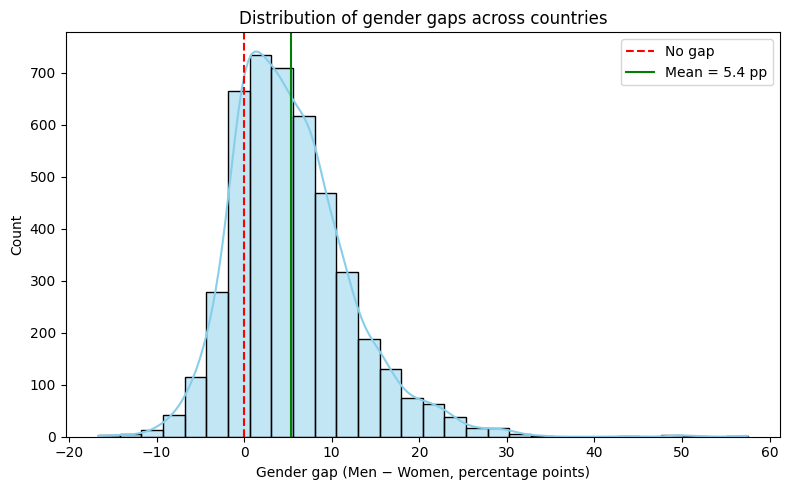

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(
    test_data['gender_gap_pp'],bins=30, kde=True, color='skyblue'
)

plt.axvline(0, color='red', linestyle='--', label='No gap')
plt.axvline(
    test_data['gender_gap_pp'].mean(),
    color='green',
    linestyle='-',
    label=f"Mean = {test_data['gender_gap_pp'].mean():.1f} pp"
)

plt.xlabel('Gender gap (Men − Women, percentage points)')
plt.title('Distribution of gender gaps across countries')
plt.legend()

plt.tight_layout()
plt.show()

The distribution shows that men generally have higher financial inclusion rates than women. Most gender gaps are relatively small, falling within about 0–10 percentage points, with an average gap of 5.4 percentage points.

**GLOBAL GENDER GAP**

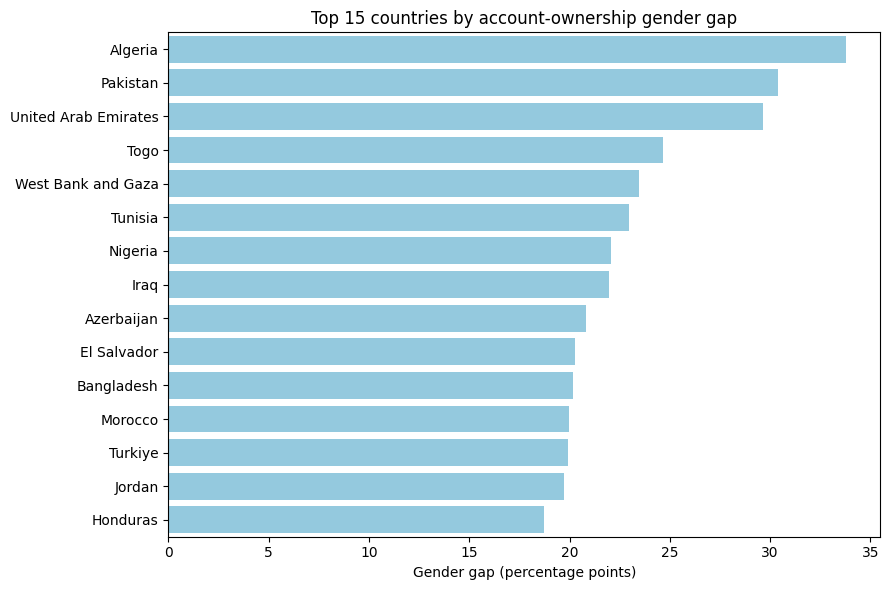

In [32]:
# Latest year for each country and indicator
idx = gender.groupby(['country', 'indicator_name'])['year'].idxmax()
latest = gender.loc[idx]

account_gap = (
    latest[latest['indicator_name'] == 'Account ownership']
    .sort_values('gender_gap_pp', ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=account_gap,
    y='country',
    x='gender_gap_pp',
    color='skyblue'
)

plt.xlabel('Gender gap (percentage points)')
plt.ylabel('')
plt.title('Top 15 countries by account-ownership gender gap')

plt.tight_layout()
plt.show()

Algeria has the largest gender gap in account ownership, followed by Pakistan and the UAE. The gaps are particularly large in several countries, showing that women still face significant barriers to account ownership.

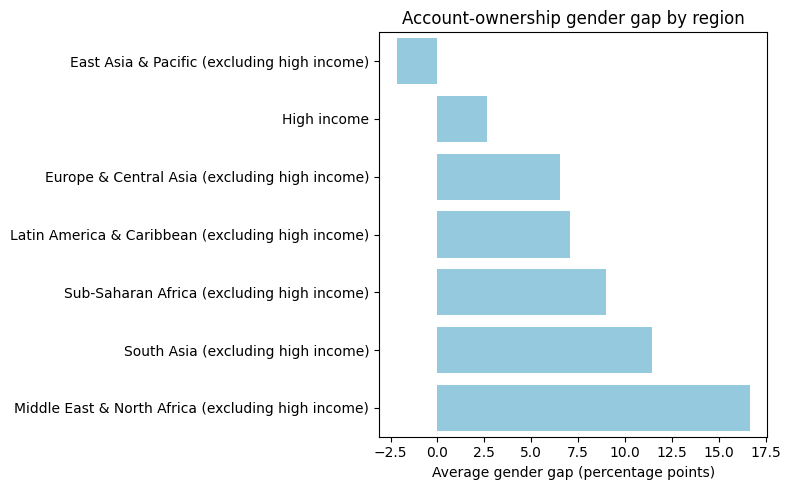

In [37]:
region_gap = (
    latest[latest['indicator_name'] == 'Account ownership']
    .groupby('region')['gender_gap_pp']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_gap.values,
    y=region_gap.index,
    color='skyblue'
)

plt.xlabel('Average gender gap (percentage points)')
plt.ylabel('')
plt.title('Account-ownership gender gap by region')

plt.tight_layout()
plt.show()

The gender gap differs across regions, with the largest gap in the Middle East & North Africa and smaller gaps in East Asia & Pacific and high-income economies.

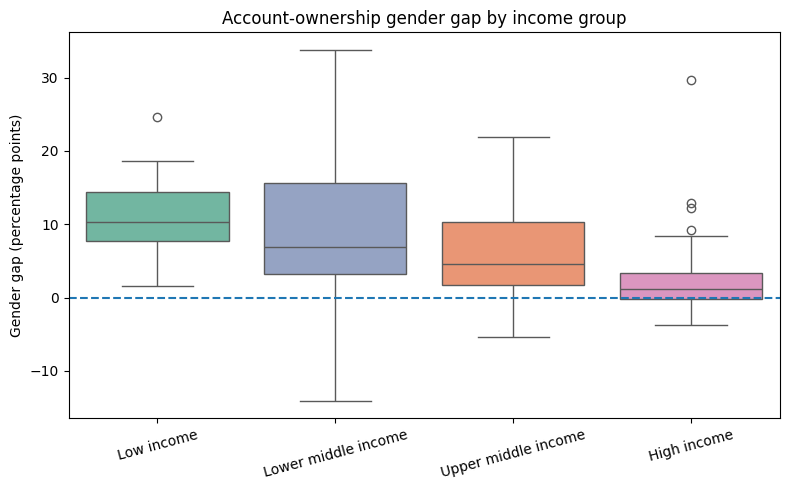

In [38]:
income_order = [
    'Low income',
    'Lower middle income',
    'Upper middle income',
    'High income'
]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=latest[latest['indicator_name'] == 'Account ownership'],
    x='income_group',
    y='gender_gap_pp',
    order=income_order,
    hue='income_group',
    palette='Set2',
    legend=False
)

plt.axhline(0, linestyle='--')
plt.title('Account-ownership gender gap by income group')
plt.xlabel('')
plt.ylabel('Gender gap (percentage points)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

The gender gap in account ownership is generally larger in lower-income economies and much smaller in high-income economies. However, the variation within each group shows that income alone does not determine the gap.

## 6. Financial Inclusion Trends Over Time

This section examines how selected financial inclusion indicators have changed over time. The analysis focuses on overall country-level trends and selected gender-disaggregated trends.

Because the dataset contains observations from multiple countries, the figures presented here represent average values across available country-level observations for each year.


In [39]:
# Annual average financial inclusion by indicator

annual_trends = (
    countries
    .groupby(['year', 'indicator_name'])['value_pct']
    .mean()
    .reset_index()
)

annual_trends.head()

,year,indicator_name,value_pct
0,2011,Account ownership,49.757563
1,2011,Bank/financial institution account,49.757563
2,2011,Debit card ownership,38.383305
3,2011,Saved at a bank/financial institution,24.023365
4,2014,Account ownership,56.515773


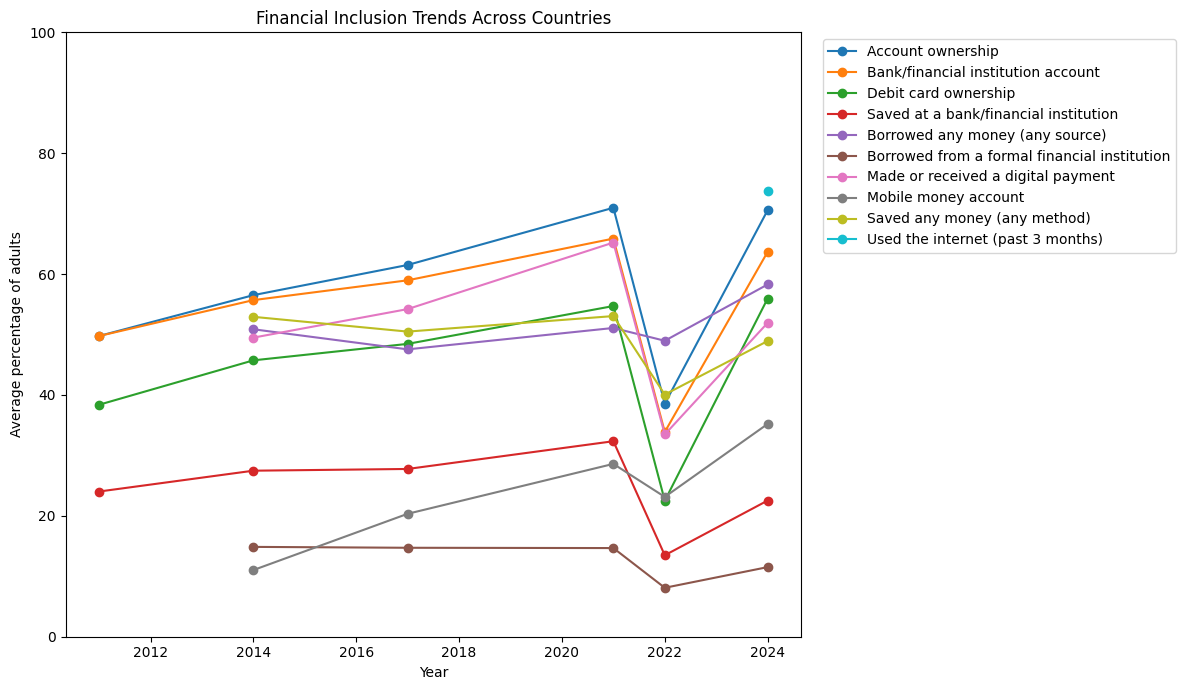

In [40]:
# Financial inclusion trends across indicators

plt.figure(figsize=(12, 7))

for indicator in annual_trends['indicator_name'].unique():
    data = annual_trends[
        annual_trends['indicator_name'] == indicator
    ]

    plt.plot(
        data['year'],
        data['value_pct'],
        marker='o',
        label=indicator
    )

plt.xlabel('Year')
plt.ylabel('Average percentage of adults')
plt.title('Financial Inclusion Trends Across Countries')
plt.ylim(0, 100)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

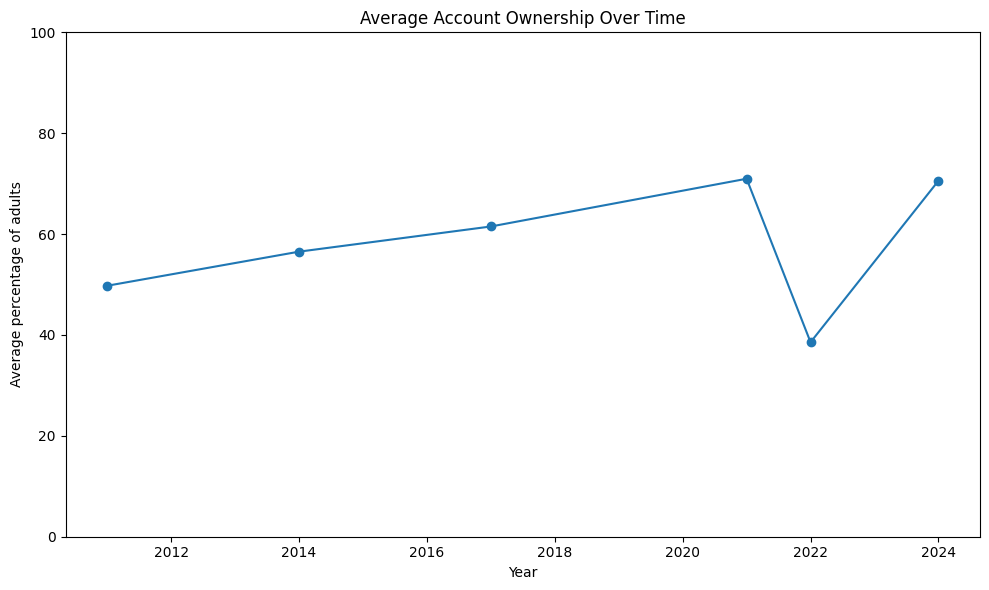

In [41]:
# Account ownership trend

account_trend = annual_trends[
    annual_trends['indicator_name'] == 'Account ownership'
]

plt.figure(figsize=(10, 6))

plt.plot(
    account_trend['year'],
    account_trend['value_pct'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Average percentage of adults')
plt.title('Average Account Ownership Over Time')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [42]:
# Change in account ownership between the first and latest available year

first_year = account_trend['year'].min()
last_year = account_trend['year'].max()

first_value = account_trend.loc[
    account_trend['year'] == first_year,
    'value_pct'
].iloc[0]

last_value = account_trend.loc[
    account_trend['year'] == last_year,
    'value_pct'
].iloc[0]

change_pp = last_value - first_value

print(f"First year: {first_year} ({first_value:.2f}%)")
print(f"Latest year: {last_year} ({last_value:.2f}%)")
print(f"Change: {change_pp:.2f} percentage points")

First year: 2011 (49.76%)
Latest year: 2024 (70.57%)
Change: 20.81 percentage points


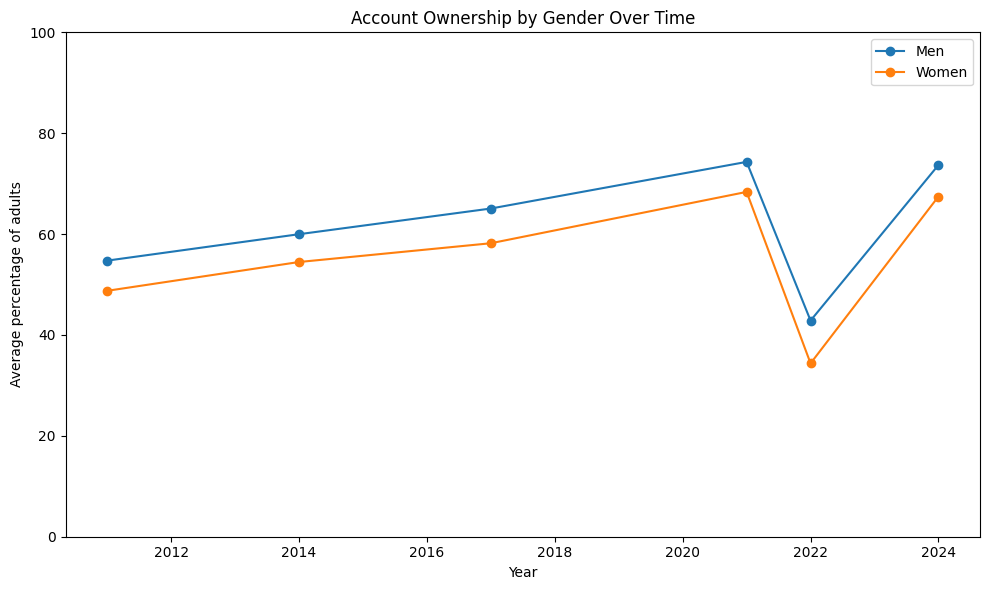

In [43]:
# Account ownership trend by gender

account_gender = countries[
    (countries['indicator_name'] == 'Account ownership') &
    (countries['gender_group'].isin(['men', 'women']))
]

account_gender_trend = (
    account_gender
    .groupby(['year', 'gender_group'])['value_pct']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for gender_group in ['men', 'women']:
    data = account_gender_trend[
        account_gender_trend['gender_group'] == gender_group
    ]

    plt.plot(
        data['year'],
        data['value_pct'],
        marker='o',
        label=gender_group.title()
    )

plt.xlabel('Year')
plt.ylabel('Average percentage of adults')
plt.title('Account Ownership by Gender Over Time')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
# Account ownership gender gap over time

account_gap = (
    account_gender_trend
    .pivot(
        index='year',
        columns='gender_group',
        values='value_pct'
    )
    .dropna()
)

account_gap['gender_gap_pp'] = (
    account_gap['men'] - account_gap['women']
)

account_gap.round(2)

gender_group,men,women,gender_gap_pp
year,,,
2011,54.74,48.75,5.99
2014,59.98,54.46,5.51
2017,65.07,58.19,6.88
2021,74.31,68.36,5.95
2022,42.85,34.37,8.48
2024,73.69,67.45,6.24


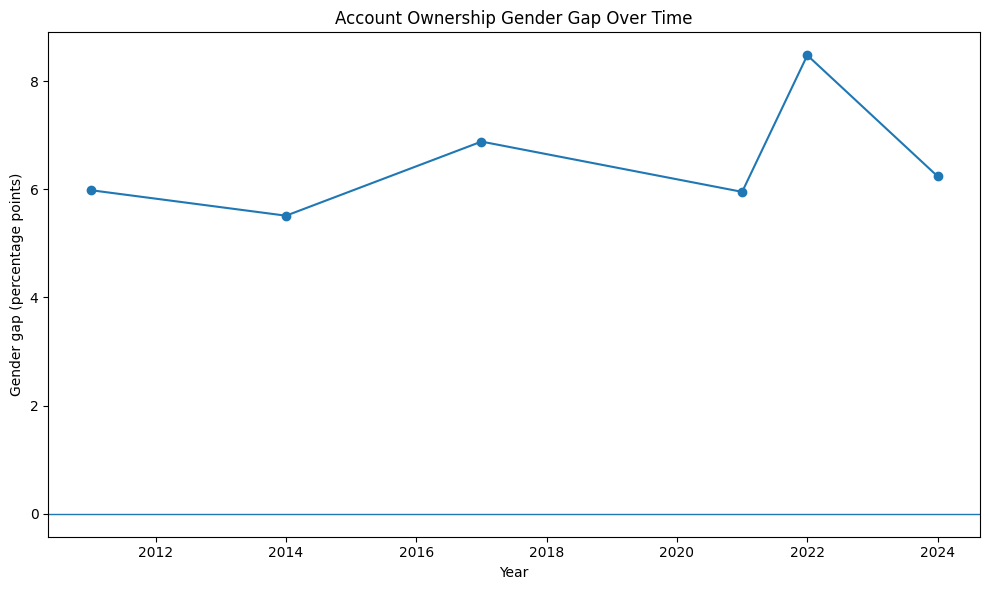

In [45]:
# Plot the account ownership gender gap

plt.figure(figsize=(10, 6))

plt.plot(
    account_gap.index,
    account_gap['gender_gap_pp'],
    marker='o'
)

plt.axhline(0, linewidth=1)

plt.xlabel('Year')
plt.ylabel('Gender gap (percentage points)')
plt.title('Account Ownership Gender Gap Over Time')

plt.tight_layout()
plt.show()

### Interpretation

The analysis shows an overall upward trend in financial inclusion over the period covered, although the pattern varies across indicators and years.

Account ownership increased from 49.76% in 2011 to 70.57% in 2024, representing an increase of 20.81 percentage points. This indicates substantial improvement in access to formal financial accounts across the countries analysed.

The broader financial inclusion trend also shows improvements in several indicators between the earliest and latest available observations. However, many indicators record a noticeable decline in 2022 followed by a strong recovery in 2024. This pattern should be interpreted cautiously, as the available observations differ across indicators and years and the analysis uses averages of country-level observations.

The gender-disaggregated results show that men consistently recorded higher average account ownership than women across all available years. The gender gap was 5.99 percentage points in 2011 and 6.24 percentage points in 2024. The largest observed gap was 8.48 percentage points in 2022.

Overall, the findings suggest that financial inclusion has expanded over time, but improvements in overall access have not completely eliminated gender disparities.

### Key finding

Account ownership increased substantially between 2011 and 2024, but a persistent gender gap remains. Although both men and women experienced higher account ownership over time, men continued to record higher average account ownership throughout the period.

## 7. Kenya Financial Inclusion Analysis

This section focuses on Kenya's financial inclusion performance across the indicators in the dataset. The analysis examines changes over time and differences between men and women, before comparing Kenya with Sub-Saharan Africa and the wider country-level results.

The purpose is to identify areas where Kenya performs relatively strongly as well as indicators where gaps remain.

In [46]:
# Filter the dataset for Kenya

kenya = countries[
    countries['country'].str.strip().str.lower() == 'kenya'
].copy()

print(f"Kenya observations: {len(kenya):,}")
print(f"Years covered: {kenya['year'].min()}–{kenya['year'].max()}")
print(f"Indicators covered: {kenya['indicator_name'].nunique()}")

Kenya observations: 123
Years covered: 2011–2024
Indicators covered: 10


In [47]:
# Kenya financial inclusion summary

kenya_summary = (
    kenya
    .groupby(['indicator_name', 'topic'])['value_pct']
    .agg(
        mean='mean',
        median='median',
        minimum='min',
        maximum='max'
    )
    .round(2)
    .sort_values('mean', ascending=False)
)

kenya_summary

,,mean,median,minimum,maximum
indicator_name,topic,,,,
Made or received a digital payment,Usage,78.85,78.26,66.90,93.24
Borrowed any money (any source),Usage,75.52,78.35,61.69,85.83
Account ownership,Access,73.67,78.66,39.18,93.89
Mobile money account,Access,71.97,70.40,54.90,91.67
Saved any money (any method),Usage,70.96,70.89,62.32,80.45
Used the internet (past 3 months),Digital access,60.66,60.49,49.63,71.86
Bank/financial institution account,Access,50.02,50.57,34.07,65.50
Debit card ownership,Access,28.93,29.94,14.40,45.45
Saved at a bank/financial institution,Usage,24.50,25.51,15.02,36.03


In [48]:
# Kenya's latest available financial inclusion indicators

kenya_latest = (
    kenya[kenya['year'] == kenya['year'].max()]
    .groupby(['indicator_name', 'topic'])['value_pct']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

kenya_latest

,,value_pct
indicator_name,topic,
Account ownership,Access,90.18
Made or received a digital payment,Usage,89.34
Mobile money account,Access,87.56
Borrowed any money (any source),Usage,81.94
Saved any money (any method),Usage,70.23
Used the internet (past 3 months),Digital access,60.66
Bank/financial institution account,Access,45.60
Saved at a bank/financial institution,Usage,20.23
Debit card ownership,Access,19.59


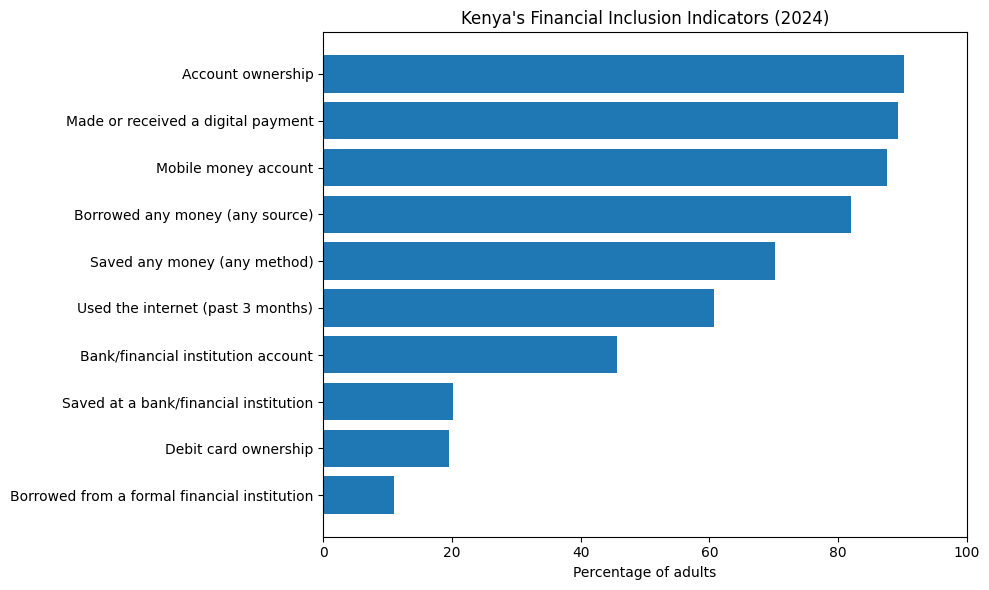

In [52]:
# Kenya's financial inclusion indicators in the latest available year

latest_year = kenya['year'].max()

plot_data = (
    kenya[kenya['year'] == latest_year]
    .groupby(['indicator_name', 'topic'])['value_pct']
    .mean()
    .reset_index()
    .sort_values('value_pct', ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data['indicator_name'],
    plot_data['value_pct']
)

plt.xlabel('Percentage of adults')
plt.ylabel('')
plt.title(f"Kenya's Financial Inclusion Indicators ({latest_year})")
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

In [53]:
# Kenya annual financial inclusion trends

kenya_trends = (
    kenya
    .groupby(['year', 'indicator_name'])['value_pct']
    .mean()
    .reset_index()
)

kenya_trends.head()

,year,indicator_name,value_pct
0,2011,Account ownership,42.390000
1,2011,Bank/financial institution account,42.390000
2,2011,Debit card ownership,30.006667
3,2011,Saved at a bank/financial institution,23.340000
4,2014,Account ownership,74.816667


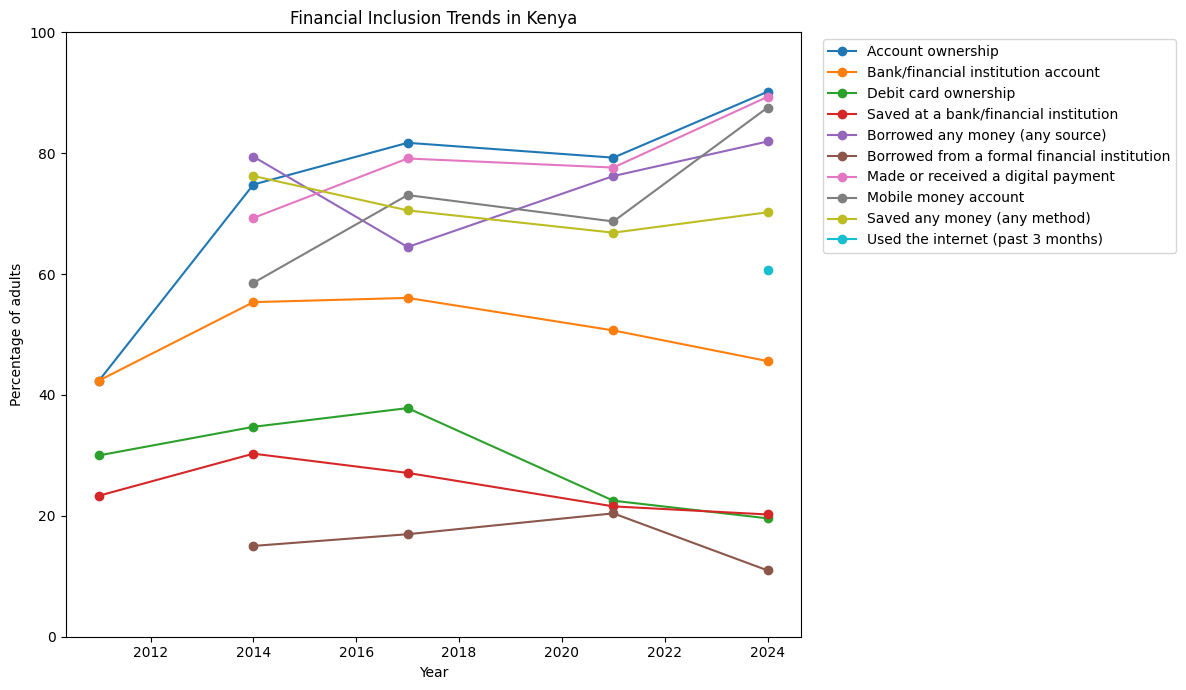

In [54]:
# Kenya financial inclusion trends across all indicators

plt.figure(figsize=(12, 7))

for indicator in kenya_trends['indicator_name'].unique():
    data = kenya_trends[
        kenya_trends['indicator_name'] == indicator
    ]

    plt.plot(
        data['year'],
        data['value_pct'],
        marker='o',
        label=indicator
    )

plt.xlabel('Year')
plt.ylabel('Percentage of adults')
plt.title('Financial Inclusion Trends in Kenya')
plt.ylim(0, 100)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

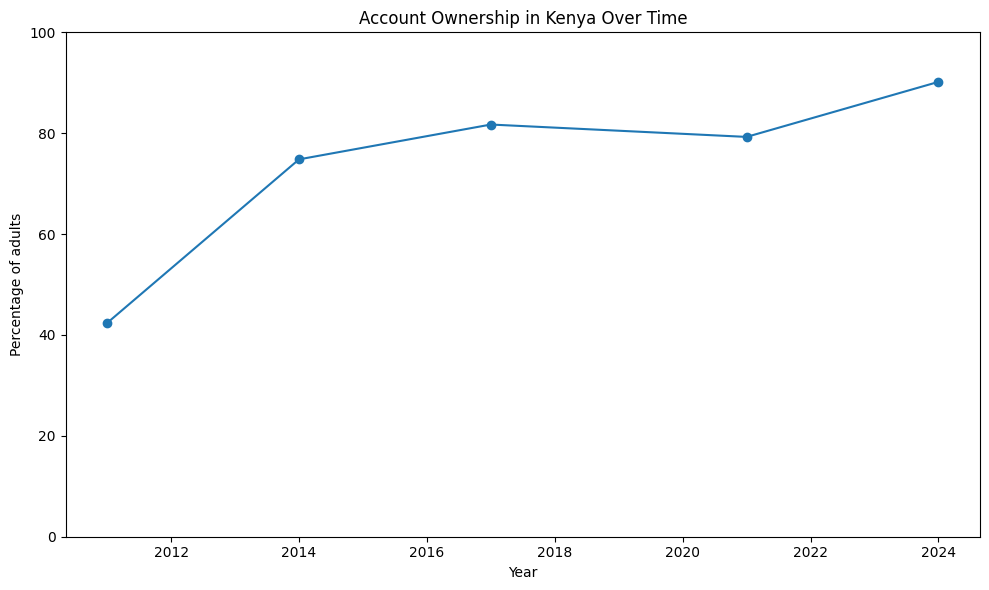

In [55]:
# Kenya account ownership trend

kenya_account = kenya_trends[
    kenya_trends['indicator_name'] == 'Account ownership'
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    kenya_account['year'],
    kenya_account['value_pct'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Percentage of adults')
plt.title('Account Ownership in Kenya Over Time')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [56]:
# Change in Kenya account ownership

first_year = kenya_account['year'].min()
last_year = kenya_account['year'].max()

first_value = kenya_account.loc[
    kenya_account['year'] == first_year,
    'value_pct'
].iloc[0]

last_value = kenya_account.loc[
    kenya_account['year'] == last_year,
    'value_pct'
].iloc[0]

change_pp = last_value - first_value

print(f"First year: {first_year} ({first_value:.2f}%)")
print(f"Latest year: {last_year} ({last_value:.2f}%)")
print(f"Change: {change_pp:.2f} percentage points")

First year: 2011 (42.39%)
Latest year: 2024 (90.18%)
Change: 47.79 percentage points


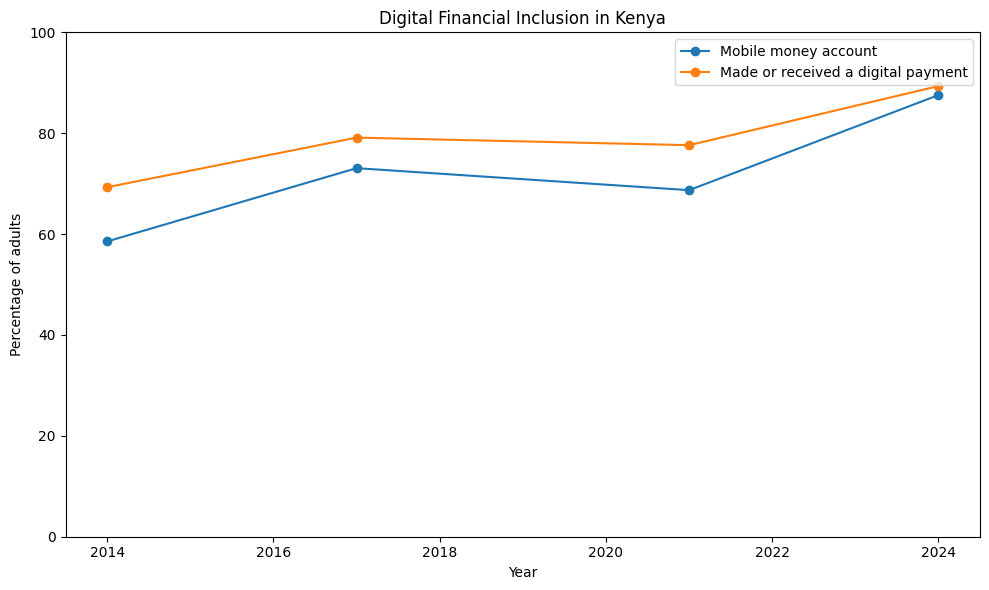

In [57]:
# Kenya digital financial inclusion trends

digital_indicators = [
    'Mobile money account',
    'Made or received a digital payment'
]

kenya_digital = kenya_trends[
    kenya_trends['indicator_name'].isin(digital_indicators)
]

plt.figure(figsize=(10, 6))

for indicator in digital_indicators:
    data = kenya_digital[
        kenya_digital['indicator_name'] == indicator
    ]

    plt.plot(
        data['year'],
        data['value_pct'],
        marker='o',
        label=indicator
    )

plt.xlabel('Year')
plt.ylabel('Percentage of adults')
plt.title('Digital Financial Inclusion in Kenya')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

### Interpretation

Kenya recorded substantial growth in financial inclusion between 2011 and 2024. Account ownership increased from 42.39% in 2011 to 90.18% in 2024, representing a gain of 47.79 percentage points.

The results also show strong growth in digital financial services. Mobile money account ownership increased from 58.81% in 2014 to 87.56% in 2024, while the proportion of adults who made or received a digital payment increased from 69.96% to 89.34% over the same period.

The trend is not completely linear. Several indicators show a decline between 2017 and 2021 before recovering by 2024. Despite these fluctuations, the latest observations generally indicate substantially higher levels of financial inclusion than the earlier observations.

Kenya's results also show an important distinction between different forms of financial inclusion. Digital and account-based services have relatively high levels of adoption, while indicators associated with traditional formal financial institutions, such as saving at a bank or financial institution and formal borrowing, remain considerably lower.

Overall, the findings indicate that Kenya has experienced substantial expansion in financial inclusion, with digital financial services forming an important part of this development.

### Key finding

Kenya's strongest gains are observed in account ownership and digital financial services. Account ownership increased by 47.79 percentage points between 2011 and 2024, while mobile money and digital payment use reached 87.56% and 89.34%, respectively, in 2024.

## 8. Gender Gap in Financial Inclusion in Kenya

This section examines differences in financial inclusion between men and women in Kenya. The gender gap is calculated as the percentage of men accessing or using a financial service minus the corresponding percentage for women.

A positive gap indicates higher financial inclusion among men, while a negative gap indicates higher financial inclusion among women.

In [58]:
# Prepare Kenya gender data

kenya_gender = kenya[
    kenya['gender_group'].isin(['men', 'women'])
].copy()

kenya_gender_pivot = (
    kenya_gender
    .pivot_table(
        index=['year', 'indicator_name'],
        columns='gender_group',
        values='value_pct'
    )
    .reset_index()
)

kenya_gender_pivot['gender_gap_pp'] = (
    kenya_gender_pivot['men'] -
    kenya_gender_pivot['women']
)

kenya_gender_pivot.head()

gender_group,year,indicator_name,men,women,gender_gap_pp
0,2011,Account ownership,45.65,39.18,6.47
1,2011,Bank/financial institution account,45.65,39.18,6.47
2,2011,Debit card ownership,34.78,25.30,9.48
3,2011,Saved at a bank/financial institution,27.54,19.20,8.34
4,2014,Account ownership,78.66,71.13,7.53


In [59]:
# Average gender gap in Kenya by indicator

kenya_gender_gap = (
    kenya_gender_pivot
    .groupby('indicator_name')['gender_gap_pp']
    .agg(
        mean_gap='mean',
        median_gap='median',
        observations='count'
    )
    .round(2)
    .sort_values('mean_gap', ascending=False)
)

kenya_gender_gap

,mean_gap,median_gap,observations
indicator_name,,,
Used the internet (past 3 months),22.23,22.23,1
Bank/financial institution account,13.43,11.93,5
Saved at a bank/financial institution,10.83,10.49,5
Debit card ownership,9.55,9.69,5
Saved any money (any method),8.44,8.69,4
Account ownership,7.47,7.53,5
Made or received a digital payment,7.37,7.77,4
Borrowed from a formal financial institution,7.30,7.33,4
Mobile money account,7.13,7.49,4


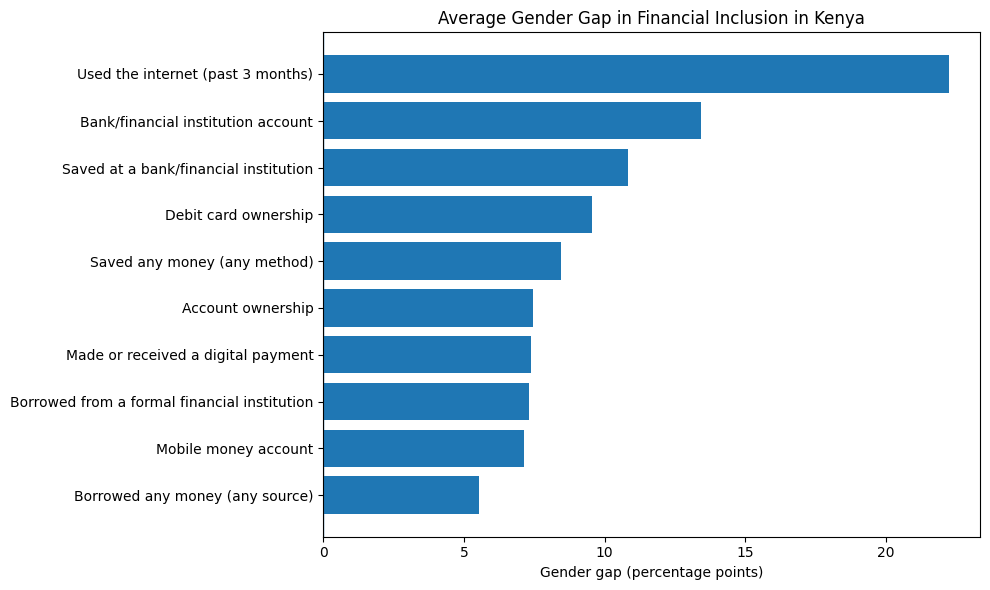

In [60]:
# Average gender gap in Kenya

plot_data = kenya_gender_gap.sort_values('mean_gap')

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data.index,
    plot_data['mean_gap']
)

plt.axvline(0, linewidth=1)

plt.xlabel('Gender gap (percentage points)')
plt.ylabel('')
plt.title('Average Gender Gap in Financial Inclusion in Kenya')

plt.tight_layout()
plt.show()

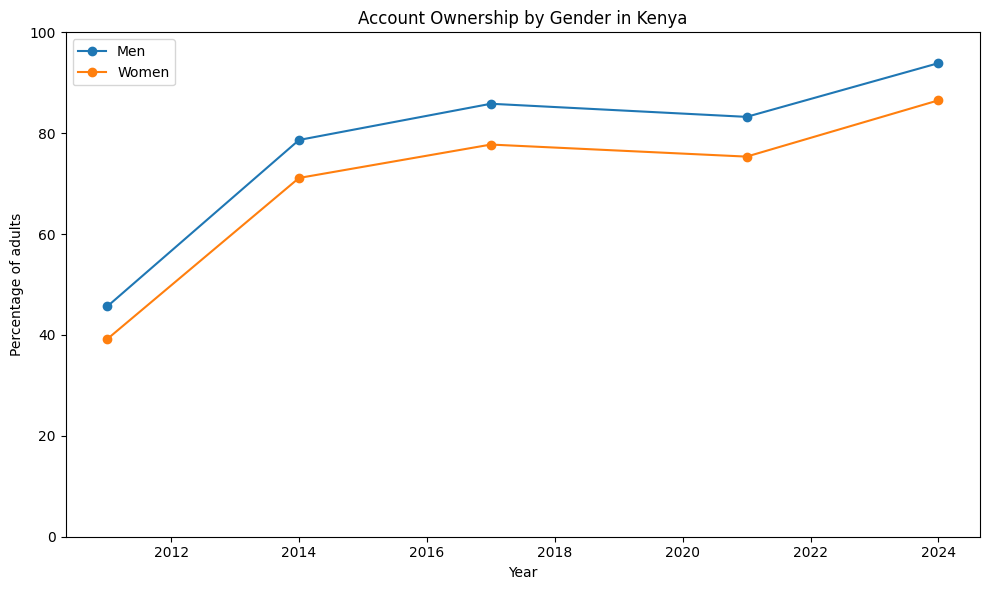

In [61]:
# Kenya account ownership by gender over time

kenya_account_gender = kenya_gender_pivot[
    kenya_gender_pivot['indicator_name'] == 'Account ownership'
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    kenya_account_gender['year'],
    kenya_account_gender['men'],
    marker='o',
    label='Men'
)

plt.plot(
    kenya_account_gender['year'],
    kenya_account_gender['women'],
    marker='o',
    label='Women'
)

plt.xlabel('Year')
plt.ylabel('Percentage of adults')
plt.title('Account Ownership by Gender in Kenya')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

In [62]:
# Kenya account ownership gender gap over time

kenya_account_gap = kenya_account_gender[
    ['year', 'gender_gap_pp']
].copy()

kenya_account_gap

gender_group,year,gender_gap_pp
0,2011,6.47
4,2014,7.53
13,2017,8.09
22,2021,7.88
31,2024,7.37


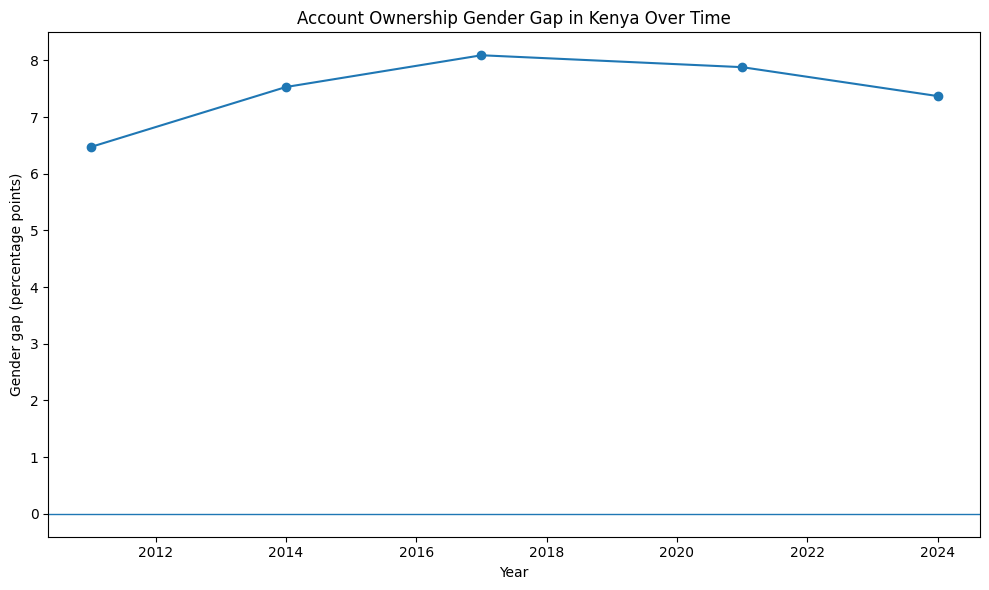

In [63]:
# Plot Kenya's account ownership gender gap

plt.figure(figsize=(10, 6))

plt.plot(
    kenya_account_gap['year'],
    kenya_account_gap['gender_gap_pp'],
    marker='o'
)

plt.axhline(0, linewidth=1)

plt.xlabel('Year')
plt.ylabel('Gender gap (percentage points)')
plt.title('Account Ownership Gender Gap in Kenya Over Time')

plt.tight_layout()
plt.show()

Account ownership rose strongly for both men and women, but men remained consistently ahead. In contrast, formal bank account ownership declined after 2017, especially among women, widening the gender gap by 2024.

**Gender Differences in Financial Inclusion Indicators, Kenya, 2024**

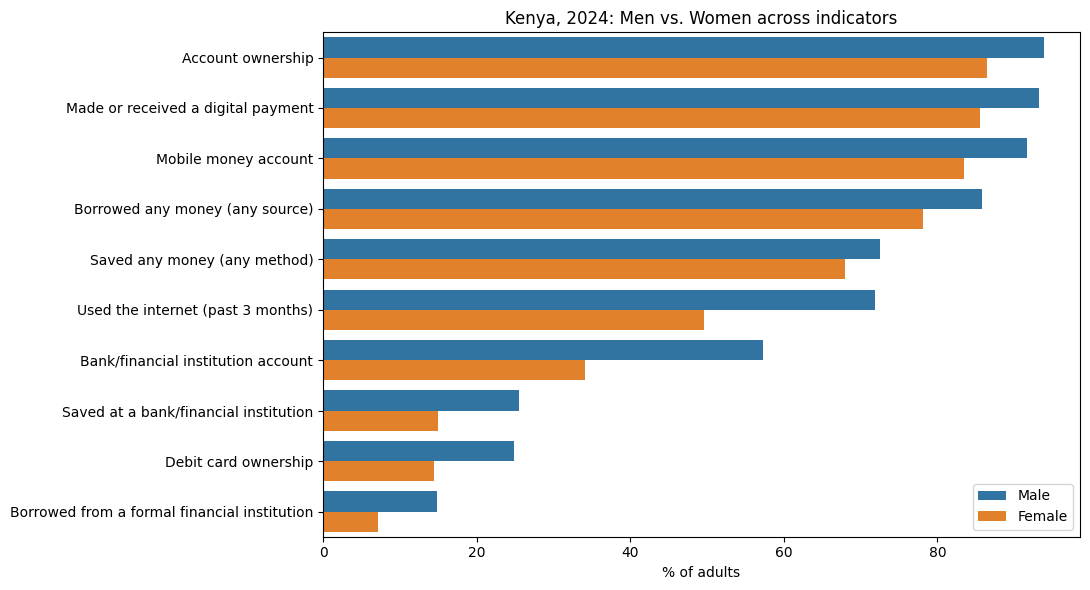

In [ ]:
# Select the latest year
latest = kenya[kenya['year'] == kenya['year'].max()]

# Arrange indicators by their average value
order = (
    latest.groupby('indicator_name')['value_pct']
    .mean()
    .sort_values(ascending=False)
    .index
)

# Create the chart
plt.figure(figsize=(11, 6))

sns.barplot(
    data=latest,
    y='indicator_name',
    x='value_pct',
    hue='gender_group',
    order=order
)

plt.title('Kenya, 2024: Men vs. Women across indicators')
plt.xlabel('% of adults')
plt.ylabel('')
plt.legend(title='')

plt.tight_layout()
plt.show()

The chart shows that men have higher financial inclusion levels than women across all indicators in 2024. The largest gaps appear in internet use and formal financial institution accounts, while the differences are smaller for borrowing and saving through any method.

**GENDER GAP BY INDICATOR AND SURVEY YEAR**

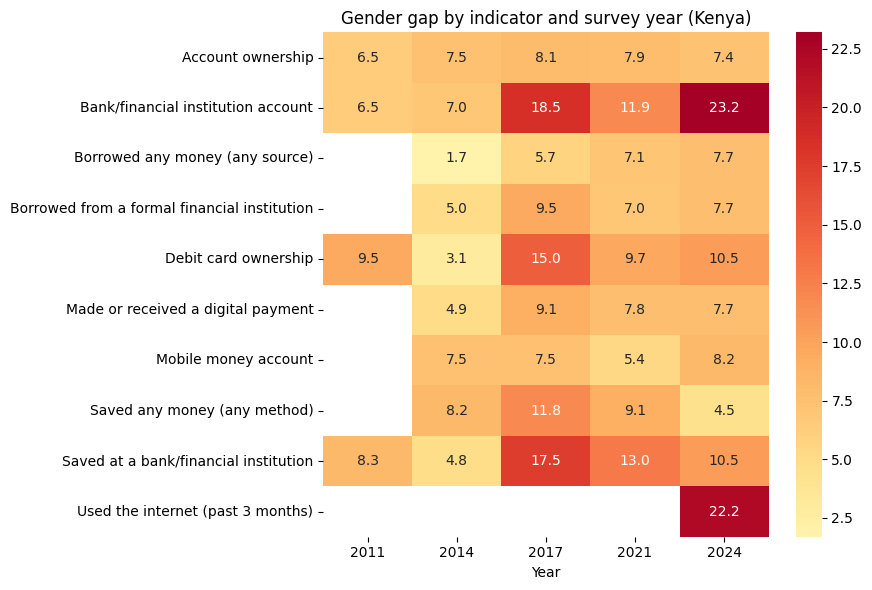

In [ ]:
# Calculate Male - Female gap for each indicator and year
gap_df = (
    kenya
    .pivot_table(
        index='indicator_name',
        columns=['year', 'gender_group'],
        values='value_pct'
    )
)

gap_df = gap_df.xs('Male', level='gender_group', axis=1) - \
         gap_df.xs('Female', level='gender_group', axis=1)

gap_df = gap_df.round(1)

# Display the gender gap as a heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(
    gap_df,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    center=0
)

plt.title('Gender gap by indicator and survey year (Kenya)')
plt.xlabel('Year')
plt.ylabel('')
plt.tight_layout()
plt.show()

The gender gap is generally positive across the indicators, meaning men recorded higher financial inclusion levels than women. The largest gaps were seen in formal banking and internet use, particularly in 2024, while gaps in mobile money, saving and borrowing were generally smaller.

**HYPOTHESIS TESTING**

The line chart showed a small, stable gap in overall account ownership but a larger, widening gap in formal bank account ownership. We test this difference using a paired-samples t-test based on the five matched survey years.

**Null hypothesis (H₀)**: There is no statistically significant difference between the mean financial inclusion rates of men and women.
**Alternative hypothesis (H₁)**: There is a statistically significant difference between the mean financial inclusion rates of men and women.
**Significance level (α)**: 0.05

In [ ]:
def paired_ttest(indicator):
    data = kenya[kenya['indicator_name'] == indicator]

    wide = (
        data.pivot(
            index='year',
            columns='gender_group',
            values='value_pct'
        )
        .dropna()
    )

    t_stat, p_val = stats.ttest_rel(
        wide['Male'],
        wide['Female']
    )

    gap = wide['Male'] - wide['Female']

    return {
        'Indicator': indicator,
        'Years': len(wide),
        'Mean Male (%)': wide['Male'].mean(),
        'Mean Female (%)': wide['Female'].mean(),
        'Mean Gap (pp)': gap.mean(),
        't-statistic': t_stat,
        'p-value': p_val,
        'df': len(wide) - 1
    }


results = pd.DataFrame([
    paired_ttest('Account ownership'),
    paired_ttest('Bank/financial institution account')
])

results.round(3)

,Indicator,Years,Mean Male (%),Mean Female (%),Mean Gap (pp),t-statistic,p-value,df
0,Account ownership,5,77.456,69.988,7.468,26.688,0.000,4
1,Bank/financial institution account,5,56.816,43.384,13.432,4.100,0.015,4


Both indicators show a significant gender gap. Account ownership is about 7.5 percentage points higher for men, while the gap in formal bank account ownership is larger at 13.4 percentage points. Both differences are statistically significant (p < 0.05).

## 9. Kenya vs Sub-Saharan Africa and Global

This section compares Kenya's latest financial inclusion indicators with the Sub-Saharan Africa regional average and the overall country-level average in the dataset.

In [64]:
# Kenya vs Sub-Saharan Africa vs Global comparison
# Latest available year

latest_year = countries['year'].max()

# Global country-level average
global_latest = (
    countries[countries['year'] == latest_year]
    .groupby('indicator_name')['value_pct']
    .mean()
)

# Sub-Saharan Africa average
ssa_latest = (
    countries[
        (countries['year'] == latest_year) &
        (countries['region'].str.contains('Sub-Saharan Africa', case=False, na=False))
    ]
    .groupby('indicator_name')['value_pct']
    .mean()
)

# Kenya
kenya_latest_values = (
    kenya[kenya['year'] == latest_year]
    .groupby('indicator_name')['value_pct']
    .mean()
)

comparison = pd.DataFrame({
    'Kenya': kenya_latest_values,
    'Sub-Saharan Africa': ssa_latest,
    'Global': global_latest
}).round(2)

comparison

,Kenya,Sub-Saharan Africa,Global
indicator_name,,,
Account ownership,90.18,55.68,70.57
Bank/financial institution account,45.60,31.48,63.68
Borrowed any money (any source),81.94,70.16,58.29
Borrowed from a formal financial institution,10.97,7.73,11.52
Debit card ownership,19.59,21.58,55.96
Made or received a digital payment,89.34,50.50,51.94
Mobile money account,87.56,44.66,35.21
Saved any money (any method),70.23,58.23,48.93
Saved at a bank/financial institution,20.23,18.00,22.53


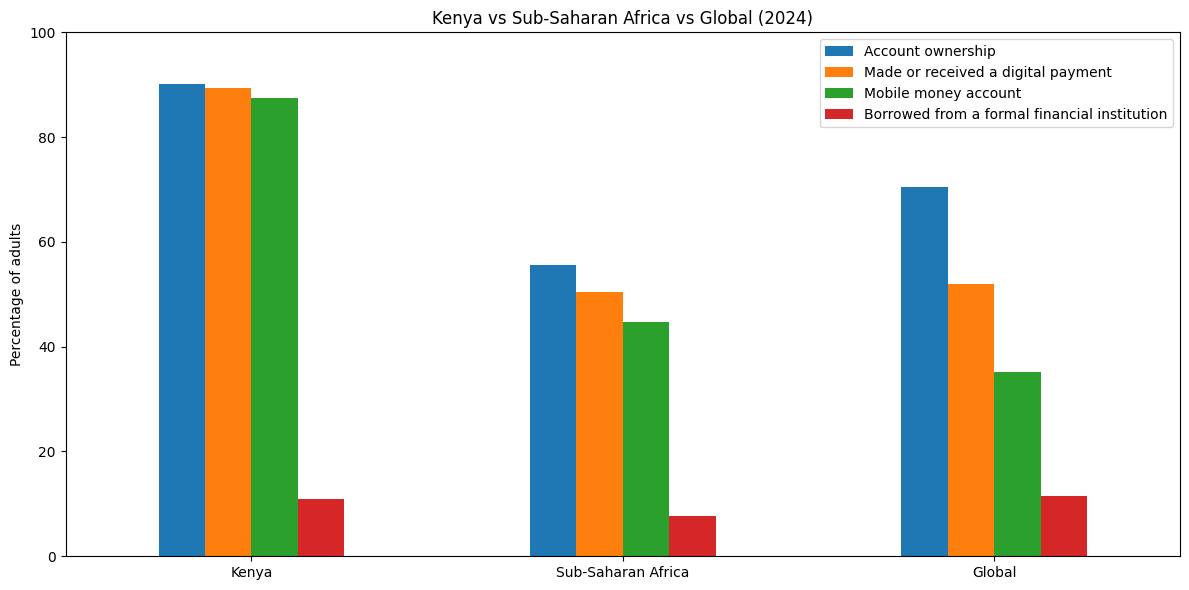

In [66]:
# Compare selected key indicators

selected_indicators = [
    'Account ownership',
    'Made or received a digital payment',
    'Mobile money account',
    'Borrowed from a formal financial institution'
]

comparison.loc[selected_indicators].T.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.ylabel('Percentage of adults')
plt.xlabel('')
plt.title(f'Kenya vs Sub-Saharan Africa vs Global ({latest_year})')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title='')

plt.tight_layout()
plt.show()

## 10. Key Findings and Recommendations

### Key Findings

1. **Financial inclusion has improved over time.**  
   Across the countries analysed, account ownership increased substantially between the earliest and latest observations, although trends varied across indicators and years.

2. **Gender disparities remain.**  
   Men recorded higher average financial inclusion than women across the matched observations, with an overall average gender gap of 5.40 percentage points.

3. **Kenya records strong financial inclusion levels.**  
   In 2024, account ownership in Kenya stood at 90.18%, while digital payment use and mobile money account ownership stood at 89.34% and 87.56%, respectively.

4. **Digital financial services are particularly important in Kenya.**  
   The relatively high levels of mobile money and digital payment use demonstrate the importance of digital channels in expanding access to financial services.

5. **Traditional formal financial services remain less widely used.**  
   Saving at a bank or financial institution, debit card ownership and formal borrowing recorded substantially lower levels than account ownership and digital financial services in Kenya.

6. **The gender gap has not disappeared despite overall progress.**  
   Kenya's account ownership gender gap remained positive across the observed years, indicating that improvements in overall account ownership have not completely eliminated differences between men and women.

### Recommendations

- Strengthen initiatives that address barriers to financial inclusion among women.
- Promote affordable and accessible digital financial services, particularly for underserved groups.
- Support financial literacy and awareness programmes that encourage the effective use of formal financial services.
- Encourage products that respond to the saving and borrowing needs of underserved consumers.
- Continue monitoring gender-disaggregated financial inclusion indicators to identify areas where disparities persist.


## 11. Conclusion

This analysis examined financial inclusion across countries, gender differences, trends over time and Kenya's position relative to regional and global benchmarks.

The findings show that financial inclusion has generally expanded, while gender disparities remain. Kenya demonstrates particularly strong adoption of account ownership, mobile money and digital payments, highlighting the importance of digital financial services in expanding financial access.

However, the relatively lower use of traditional formal financial services and the persistence of gender differences indicate that increased access does not necessarily translate into equal or comprehensive use of financial services.

Overall, the analysis highlights the importance of combining broader financial inclusion efforts with targeted interventions that address persistent gender and product-specific gaps.